# Import Libraries

In [1]:
import os
import math
import time
import random
import shutil
import itertools
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from multiprocessing import Pool, cpu_count
from tqdm import tqdm, trange

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import brevitas.nn as qnn
from brevitas.nn import QuantLinear, QuantReLU, QuantConv2d
from brevitas.quant.binary import SignedBinaryActPerTensorConst
from brevitas.quant.binary import SignedBinaryWeightPerTensorConst
from brevitas.inject.enum import QuantType
from brevitas.quant_tensor.int_quant_tensor import IntQuantTensor
from brevitas.function.ops_ste import round_ste

Matplotlib created a temporary cache directory at /tmp/matplotlib-m3uogor1 because the default path (/home/hippocampus/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


/home/hippocampus/.conda/envs/brevitas/lib/python3.9/site-packages/brevitas/__init__.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


# Network Definition

#### Neuron number and precision in each layer listed in this area for the MLP used in MNIST classification

In [2]:
kernel_num_CONV_layer_0_0 = 64
kernel_num_CONV_layer_0_1 = 64

kernel_num_CONV_layer_1_0 = 128
kernel_num_CONV_layer_1_1 = 128

kernel_num_CONV_layer_2_0 = 256
kernel_num_CONV_layer_2_1 = 256

neuron_num_FC_layer_0 = 512
neuron_num_FC_layer_1 = 512
neuron_num_OUT_layer  = 10

precision_CONV_layer_0_0 = 4
precision_CONV_layer_0_1 = 4

precision_CONV_layer_1_0 = 2
precision_CONV_layer_1_1 = 2

precision_CONV_layer_2_0 = 1
precision_CONV_layer_2_1 = 1

precision_FC_layer_0 = 4
precision_FC_layer_1 = 2
precision_OUT_layer  = 1

#### Hyperparameters setting here.

In [3]:
epochs = 100
batch_sizes = [128]
dropout_rates = [0.0, 0.05, 0.1]
lr_max_pool = [0.001, 0.0005]
lr_min_pool = [0.00001, 0.000001]

#### GPU selection. After decided which GPU to train, don't change it before completing the training

In [4]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [5]:
GPU_device = "cuda:0"

#### Training date output folder path, for different network model setting, please change the name of save_path

In [6]:
save_path     = "CNV_mixed_421_421bit"

project_root  = os.path.abspath(".")
dataset_root  = os.path.join(project_root, "dataset/SVHN")
train_root    = os.path.join(project_root, "train")
output_root   = os.path.join(train_root, save_path)
report_root  = os.path.join(project_root, "report")

print("Dataset Download Path: ", dataset_root, "\n")
print("Training Data Output Path: ", output_root, "\n")
print("Training Report Output Path: ", report_root)

os.makedirs(dataset_root, exist_ok=True)
os.makedirs(output_root, exist_ok=True)
os.makedirs(report_root, exist_ok=True)

Dataset Download Path:  /home/hippocampus/workspace/Projects/Software/Python/QModels-Brevitas-Example/brevitas_std_qnn/classification/SVHN/perTensor/dataset/SVHN 

Training Data Output Path:  /home/hippocampus/workspace/Projects/Software/Python/QModels-Brevitas-Example/brevitas_std_qnn/classification/SVHN/perTensor/train/CNV_mixed_421_421bit 

Training Report Output Path:  /home/hippocampus/workspace/Projects/Software/Python/QModels-Brevitas-Example/brevitas_std_qnn/classification/SVHN/perTensor/report


#### Following are the code to complete the network definition

In [7]:
def int_range(act_bit_width):
    if (act_bit_width>1):
        min_val = -2.0**(act_bit_width-1.0)
        max_val = 2.0**(act_bit_width-1.0)-1.0
    else:
        min_val = -1.0
        max_val = 1.0
    return min_val, max_val

In [8]:
kernel_size      = (3,3) 

In [9]:
in_channel_0_0   = 3
out_channel_0_0  = kernel_num_CONV_layer_0_0 
in_channel_0_1   = kernel_num_CONV_layer_0_0
out_channel_0_1  = kernel_num_CONV_layer_0_1 

in_channel_1_0   = kernel_num_CONV_layer_0_1
out_channel_1_0  = kernel_num_CONV_layer_1_0
in_channel_1_1   = kernel_num_CONV_layer_1_0
out_channel_1_1  = kernel_num_CONV_layer_1_1 

in_channel_2_0   = kernel_num_CONV_layer_1_1
out_channel_2_0  = kernel_num_CONV_layer_2_0
in_channel_2_1   = kernel_num_CONV_layer_2_0
out_channel_2_1  = kernel_num_CONV_layer_2_1 

input_length     = 4*4*kernel_num_CONV_layer_2_1

hidden_0         = neuron_num_FC_layer_0  
hidden_1         = neuron_num_FC_layer_1

output_length    = neuron_num_OUT_layer 

In [10]:
conv_0_0_bit_width = precision_CONV_layer_0_0
conv_0_1_bit_width = precision_CONV_layer_0_1

conv_1_0_bit_width = precision_CONV_layer_1_0
conv_1_1_bit_width = precision_CONV_layer_1_1

conv_2_0_bit_width = precision_CONV_layer_2_0
conv_2_1_bit_width = precision_CONV_layer_2_1

fc_0_bit_width = precision_FC_layer_0
fc_1_bit_width = precision_FC_layer_1
out_bit_width  = precision_OUT_layer

In [11]:
min_val, max_val = int_range(conv_0_0_bit_width)

In [12]:
class CNV(nn.Module):
    def __init__(self, dropout=0.5):
        super(CNV, self).__init__()
        
        self.input_bin  = qnn.QuantIdentity(
                         quant_type='binary',
                         scaling_impl_type='stats',
                         bit_width=conv_0_0_bit_width,
                         return_quant_tensor=True)
        self.input_quan = qnn.QuantIdentity(
                         quant_type='int',
                         scaling_impl_type='stats',
                         bit_width=conv_0_0_bit_width,
                         return_quant_tensor=True)
        
        self.conv0_0_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_0_0,
                         out_channels=out_channel_0_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_0_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv0_0_quan = qnn.QuantConv2d(
                         in_channels=in_channel_0_0,
                         out_channels=out_channel_0_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_0_0_bit_width,
                         weight_quant_type=QuantType.INT, 
                         bias=False)
        self.bn0_0   = nn.BatchNorm2d(out_channel_0_0)
        self.act0_0  = qnn.QuantReLU(
                         bit_width=conv_0_1_bit_width, 
                         return_quant_tensor=True)
        self.drop0_0 = nn.Dropout2d(dropout)
        
        self.conv0_1_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_0_1,
                         out_channels=out_channel_0_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_0_1_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv0_1_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_0_1,
                         out_channels=out_channel_0_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_0_1_bit_width,
                         weight_quant_type=QuantType.INT, 
                         bias=False)
        self.bn0_1   = nn.BatchNorm2d(out_channel_0_1)
        self.act0_1  = qnn.QuantReLU(
                         bit_width=conv_1_0_bit_width, 
                         return_quant_tensor=True)
        self.drop0_1 = nn.Dropout2d(dropout)
        
        self.pool0 = nn.MaxPool2d(2)
        
        self.conv1_0_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_1_0,
                         out_channels=out_channel_1_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_1_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv1_0_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_1_0,
                         out_channels=out_channel_1_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_1_0_bit_width,
                         weight_quant_type=QuantType.INT, 
                         bias=False, 
                         return_quant_tensor=True)
        self.bn1_0   = nn.BatchNorm2d(out_channel_1_0)
        self.act1_0  = qnn.QuantReLU(
                         bit_width=conv_1_1_bit_width, 
                         return_quant_tensor=True)
        self.drop1_0 = nn.Dropout2d(dropout)
        
        self.conv1_1_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_1_1,
                         out_channels=out_channel_1_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_1_1_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv1_1_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_1_1,
                         out_channels=out_channel_1_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_1_1_bit_width,
                         weight_quant_type=QuantType.INT, 
                         bias=False, 
                         return_quant_tensor=True)
        self.bn1_1   = nn.BatchNorm2d(out_channel_1_1)
        self.act1_1  = qnn.QuantReLU(
                         bit_width=conv_2_0_bit_width, 
                         return_quant_tensor=True)
        self.drop1_1 = nn.Dropout2d(dropout)
        
        self.pool1 = nn.MaxPool2d(2)
        
        self.conv2_0_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_2_0,
                         out_channels=out_channel_2_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_2_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv2_0_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_2_0,
                         out_channels=out_channel_2_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_2_0_bit_width,
                         weight_quant_type=QuantType.INT, 
                         bias=False, 
                         return_quant_tensor=True)
        self.bn2_0   = nn.BatchNorm2d(out_channel_2_0)
        self.act2_0  = qnn.QuantReLU(
                         bit_width=conv_2_1_bit_width, 
                         return_quant_tensor=True)
        self.drop2_0 = nn.Dropout2d(dropout)
        
        self.conv2_1_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_2_1,
                         out_channels=out_channel_2_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_2_1_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv2_1_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_2_1,
                         out_channels=out_channel_2_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_2_1_bit_width,
                         weight_quant_type=QuantType.INT, 
                         bias=False, 
                         return_quant_tensor=True)
        self.bn2_1   = nn.BatchNorm2d(out_channel_2_1)
        self.act2_1  = qnn.QuantReLU(
                         bit_width=fc_0_bit_width, 
                         return_quant_tensor=True)
        self.drop2_1 = nn.Dropout2d(dropout)
        
        self.pool2 = nn.MaxPool2d(2)
        
        self.fc3_bin  = qnn.QuantLinear(
                         input_length, 
                         hidden_0, 
                         weight_bit_width=fc_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.fc3_quan  = qnn.QuantLinear(
                         input_length, 
                         hidden_0, 
                         weight_bit_width=fc_0_bit_width,
                         weight_quant_type=QuantType.INT, 
                         bias=False)
        self.bn3   = nn.BatchNorm1d(hidden_0)
        self.act3  = qnn.QuantReLU(
                         bit_width=fc_1_bit_width, 
                         return_quant_tensor=True)
        self.drop3 = nn.Dropout(dropout)
        
        self.fc4_bin  = qnn.QuantLinear(
                         hidden_0, 
                         hidden_1, 
                         weight_bit_width=fc_1_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False, 
                         return_quant_tensor=True)
        self.fc4_quan = qnn.QuantLinear(
                         hidden_0, 
                         hidden_1, 
                         weight_bit_width=fc_1_bit_width,
                         weight_quant_type=QuantType.INT, 
                         bias=False, 
                         return_quant_tensor=True)
        self.bn4   = nn.BatchNorm1d(hidden_1)
        self.act4  = qnn.QuantReLU(
                         bit_width=out_bit_width, 
                         return_quant_tensor=True)
        self.drop4 = nn.Dropout(dropout)
        
        self.out_bin  = qnn.QuantLinear(
                         hidden_1, 
                         output_length, 
                         weight_bit_width=out_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.out_quan = qnn.QuantLinear(
                         hidden_1, 
                         output_length, 
                         weight_bit_width=out_bit_width,
                         weight_quant_type=QuantType.INT, 
                         bias=False)

    def forward(self, x):

        if conv_0_0_bit_width==1:
            out = self.input_bin(x)
        else:
            out = self.input_quan(x)
        
        if conv_0_0_bit_width==1:
            out = self.drop0_0(self.act0_0(self.bn0_0(self.conv0_0_bin(out))))
        else:
            out = self.drop0_0(self.act0_0(self.bn0_0(self.conv0_0_quan(out))))
            
        if conv_0_1_bit_width==1:
            out = self.drop0_1(self.act0_1(self.bn0_1(self.conv0_1_bin(out))))
        else:
            out = self.drop0_1(self.act0_1(self.bn0_1(self.conv0_1_quan(out))))
            
        out = self.pool0(out)
        
        if conv_1_0_bit_width==1:
            out = self.drop1_0(self.act1_0(self.bn1_0(self.conv1_0_bin(out))))
        else:
            out = self.drop1_0(self.act1_0(self.bn1_0(self.conv1_0_quan(out))))
            
        if conv_1_1_bit_width==1:
            out = self.drop1_1(self.act1_1(self.bn1_1(self.conv1_1_bin(out))))
        else:
            out = self.drop1_1(self.act1_1(self.bn1_1(self.conv1_1_quan(out))))
        
        out = self.pool1(out)
        
        if conv_2_0_bit_width==1:
            out = self.drop2_0(self.act2_0(self.bn2_0(self.conv2_0_bin(out))))
        else:
            out = self.drop2_0(self.act2_0(self.bn2_0(self.conv2_0_quan(out))))
            
        if conv_2_1_bit_width==1:
            out = self.drop2_1(self.act2_1(self.bn2_1(self.conv2_1_bin(out))))
        else:
            out = self.drop2_1(self.act2_1(self.bn2_1(self.conv2_1_quan(out))))
        
        out = self.pool2(out)
        
        out = out.reshape(out.shape[0], -1)

        if fc_0_bit_width==1:
            out = self.drop3(self.act3(self.bn3(self.fc3_bin(out))))
        else:
            out = self.drop3(self.act3(self.bn3(self.fc3_quan(out))))
        
        if fc_1_bit_width==1:
            out = self.drop4(self.act4(self.bn4(self.fc4_bin(out))))
        else:
            out = self.drop4(self.act4(self.bn4(self.fc4_quan(out))))

        if out_bit_width==1:
            out = self.out_bin(out)
        else:
            out = self.out_quan(out)
        
        return out

# Random Seed Utility

In [13]:
def set_random_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Define Dataloader

In [14]:
test_batch_size = 4096

In [15]:
def get_dataloaders(batch_size):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            (0.5, 0.5, 0.5),   # mean for SVHN RGB
            (0.5, 0.5, 0.5)    # std for SVHN RGB
        )
    ])

    train_dataset = datasets.SVHN(
        dataset_root,
        split="train",
        download=True,
        transform=transform
    )

    test_dataset = datasets.SVHN(
        dataset_root,
        split="test",
        download=True,
        transform=transform
    )

    val_size = int(0.2 * len(train_dataset))
    train_size = len(train_dataset) - val_size
    train_set, val_set = random_split(train_dataset, [train_size, val_size])

    return (
        DataLoader(
            train_set,
            batch_size=batch_size,
            shuffle=True,
            num_workers=6,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
        DataLoader(
            val_set,
            batch_size=batch_size,
            shuffle=False,
            num_workers=6,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
        DataLoader(
            test_dataset,
            batch_size=test_batch_size,
            shuffle=False,
            num_workers=6,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
    )

# Evaluation Pipeline

In [16]:
def evaluate(model, criterion, device, loader, train):
    model.eval()
    loss_total, correct, total = 0, 0, 0
    with torch.no_grad():
        if (train):
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                loss_total += loss.item() * x.size(0)
                _, pred = out.max(1)
                correct += (pred == y).sum().item()
                total += x.size(0)
        else:
            for x, y in tqdm(loader, desc="Evaluation", leave=True):
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                loss_total += loss.item() * x.size(0)
                _, pred = out.max(1)
                correct += (pred == y).sum().item()
                total += x.size(0)
    return loss_total / total, correct / total

# Plot Training Loss and Accuracy

In [17]:
def plot_train(history, save_dir):
    # Plot and show
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "training_plot.png"))
    plt.show()

# Training, Validation, and Testing Pipeline

In [18]:
def train_validate_test(config, save_dir):
    set_random_seed()
    os.makedirs(save_dir, exist_ok=True)
    log_file = os.path.join(save_dir, "training_log.txt")
    resume_path = os.path.join(save_dir, "checkpoint.pth")
    csv_log_path = os.path.join(save_dir, "training_log.csv")
    with open(csv_log_path, "a") as f:
        if os.path.getsize(csv_log_path) == 0:
            f.write("Epoch,Learning Rate,Train Loss,Train Acc,Val Loss,Val Acc,Epoch Time,Train Time,Val Time\n")

    epochs, batch_size, lr_max, lr_min, dropout = config
    train_loader, val_loader, test_loader = get_dataloaders(batch_size)
    device = torch.device(GPU_device if torch.cuda.is_available() else "cpu")
    model = CNV(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr_max)

    start_epoch = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "epoch_time": [], "train_time": [], "val_time": []}

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path)
        model.load_state_dict(ckpt["model_state"])
        model.to(device)
        optimizer.load_state_dict(ckpt["optimizer_state"])
        history = ckpt["history"]
        start_epoch = ckpt["epoch"] + 1
        print(f"🔄 Resuming from epoch {start_epoch}")
    else:
        with open(log_file, "w") as f:
            f.write("Training started\n")

    # Training Loop
    t = trange(start_epoch, epochs, desc="Training", leave=True)
    for epoch in t:
        epoch_start = time.time()
        model.train()
        lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * epoch / epochs))
        for g in optimizer.param_groups:
            g["lr"] = lr

        train_start = time.time()
        train_loss, correct, total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)
            _, pred = out.max(1)
            correct += (pred == y).sum().item()
            total += x.size(0)
        train_time = time.time() - train_start

        val_start = time.time()
        val_loss, val_acc = evaluate(model, criterion, device, val_loader, train=True)
        val_time = time.time() - val_start
        train_loss /= total
        train_acc = correct / total
        epoch_time = time.time() - epoch_start
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time/60)
        history["train_time"].append(train_time/60)
        history["val_time"].append(val_time/60)

        log_line = (f"Epoch {epoch+1}/{epochs} - LR: {lr:.6f} | "
                    f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                    f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | "
                    f"Epoch Time: {epoch_time/60:.2f}, Train Time: {train_time/60:.2f}, Val Time: {val_time/60:.2f}")
        
        with open(log_file, "a") as f:
            f.write(log_line + "\n")

        
        with open(os.path.join(save_dir, "training_log.csv"), "a") as f:
            f.write(f"{epoch+1},{lr:.6f},{train_loss:.4f},{train_acc:.4f},{val_loss:.4f},{val_acc:.4f},{epoch_time/60:.4f},{train_time/60:.4f},{val_time/60:.4f}\n")

        t.set_description("| LR: %.6f | Train Acc: %.4f | Val Acc: %.4f | Epoch Time: %.2f | " % (lr, train_acc, val_acc, epoch_time/60))
        t.refresh()

        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history
        }, resume_path)

    # Plot and show the training history
    plot_train(history, save_dir)

    # Test the original trained model
    original_test_loss, original_test_acc = evaluate(model, criterion, device, test_loader, train=False)
    final_line = f"Original Model Final Test Loss: {original_test_loss:.4f} Accuracy: {original_test_acc:.4f}"
    print(final_line)
    with open(log_file, "a") as f:
        f.write("Training completed\n")
        f.write(final_line + "\n")

    # Save the trained model
    torch.save(model.state_dict(), os.path.join(save_dir, "final_model.pth"))
    with open(log_file, "a") as f:
        f.write(final_line + "\n")
    print("\n")

    return original_test_acc, resume_path

# Hyperparameter Searching for Network Training and Testing

In [19]:
def Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
    
    epochs = epochs
    batch_sizes = batch_sizes
    lr_max_pool = lr_max_pool
    lr_min_pool = lr_min_pool
    
    all_runs = [
        f"batch{bs}_lr_max_{lr_max}_min_{lr_min}"
        for bs, lr_max, lr_min in itertools.product(batch_sizes, lr_max_pool, lr_min_pool)
    ]
    
    completed_runs = []
    for run in all_runs:
        log_path = os.path.join(output_root, run, "training_log.txt")
        if os.path.exists(log_path):
            with open(log_path, "r") as f:
                if any("Training completed" in line for line in f):
                    completed_runs.append(run)
    
    if len(completed_runs) == len(all_runs):
        print("✅ All combinations completed. Restarting from scratch...")
        for run in all_runs:
            shutil.rmtree(os.path.join(output_root, run), ignore_errors=True)
        if os.path.exists(os.path.join(report_root, save_path+"_report.csv")):
            os.remove(os.path.join(report_root, save_path+"_report.csv"))
        completed_runs = []
    
    results = []
    for batch_size, lr_max, lr_min, dropout in itertools.product(batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
        run_name = f"batch{batch_size}_lr_max_{lr_max}_min_{lr_min}_dp{dropout}"
        save_dir = os.path.join(output_root, run_name)
    
        if run_name in completed_runs:
            print(f"✅ Skipping {run_name}")
            with open(os.path.join(save_dir, "training_log.txt")) as f:
                for line in f:
                    if "Final Test Loss" in line:
                        acc = float(line.strip().split()[-1])
                        results.append((run_name, acc))
            continue
    
        print(f"🚀 Running: {run_name}")
        acc, resume_path = train_validate_test([epochs, batch_size, lr_max, lr_min, dropout], save_dir)
        results.append((run_name, acc, epochs, batch_size, lr_max, lr_min, dropout, resume_path))
    
    results.sort(key=lambda x: x[1], reverse=True)
    best_config, best_acc, best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path = results[0]
    
    with open(os.path.join(report_root, save_path+"_report.csv"), "w") as f:
        f.write("Epoch,Batch Size,LR_max,LR_min,Dropout,Accuracy\n")
        for name, acc, epoch, batch_size, lr_max, lr_min, dropout, resume_path in results:
            f.write(f"{epoch},{batch_size},{lr_max:.4f},{lr_min:.6f},{dropout:.4f},{acc:.4f}\n")
            
    return best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path

In [20]:
def best_evaluation(epochs, batch_size, lr_max, lr_min, dropout, resume_path):
    set_random_seed()

    epochs, batch_size, lr_max, lr_min, dropout = epochs, batch_size, lr_max, lr_min, dropout
    train_loader, val_loader, test_loader = get_dataloaders(batch_size)
    device = torch.device(GPU_device if torch.cuda.is_available() else "cpu")
    model = CNV(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr_max)

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path)
        model.load_state_dict(ckpt["model_state"])
        model.to(device)
        optimizer.load_state_dict(ckpt["optimizer_state"])
        history = ckpt["history"]
        print("Best model loaded.")
    else:
        print("Best model lost.")

    # Test the original trained model
    original_test_loss, original_test_acc = evaluate(model, criterion, device, test_loader, train=False)
    final_line = (
        f"Best Original Model Final Test Loss: {original_test_loss:.4f} "
        f"Acc: {original_test_acc:.4f} "
    )
    print(final_line)
    print("\n")

    with open(os.path.join(report_root, save_path + "_best_eval.csv"), "w") as f:
        f.write("Epoch,Batch Size,LR_max,LR_min,Dropout,Acc,Loss\n")
        f.write(f"{epochs},{batch_size},{lr_max:.4f},{lr_min:.6f},{dropout:.4f},{original_test_acc:.4f},{original_test_loss:.4f}\n")

🚀 Running: batch128_lr_max_0.001_min_1e-05_dp0.0


Using downloaded and verified file: /home/hippocampus/workspace/Projects/Software/Python/QModels-Brevitas-Example/brevitas_std_qnn/classification/SVHN/perTensor/dataset/SVHN/train_32x32.mat


Using downloaded and verified file: /home/hippocampus/workspace/Projects/Software/Python/QModels-Brevitas-Example/brevitas_std_qnn/classification/SVHN/perTensor/dataset/SVHN/test_32x32.mat


Training:   0%|          | 0/100 [00:00<?, ?it/s]

/home/hippocampus/.conda/envs/brevitas/lib/python3.9/site-packages/torch/_tensor.py:1362: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at /opt/conda/conda-bld/pytorch_1695392022560/work/c10/core/TensorImpl.h:1900.)
  return super().rename(names)


...

| LR: 0.000011 | Train Acc: 0.9999 | Val Acc: 0.9378 | Epoch Time: 0.22 | :  99%|█████████▉| 99/100 [23:14<00:13, 13.52s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9377 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [23:27<00:13, 13.52s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9377 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [23:27<00:13, 13.52s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9377 | Epoch Time: 0.23 | : 100%|██████████| 100/100 [23:27<00:00, 13.54s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9377 | Epoch Time: 0.23 | : 100%|██████████| 100/100 [23:27<00:00, 14.08s/it]

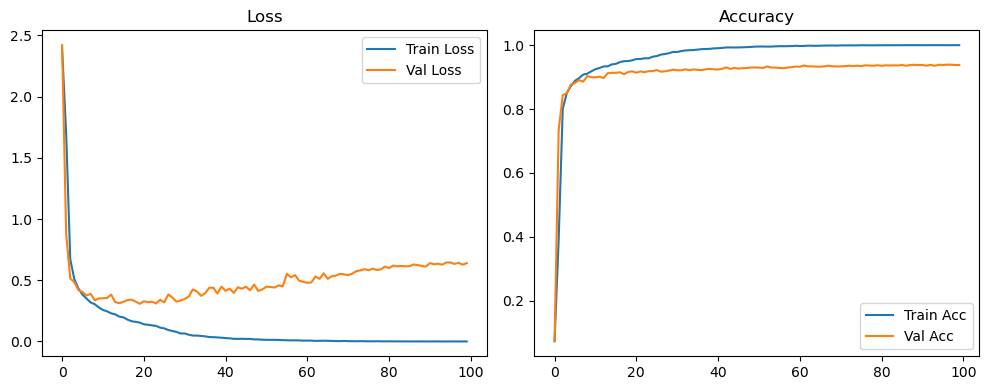

Evaluation:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|█▍        | 1/7 [00:00<00:04,  1.45it/s]

Evaluation:  29%|██▊       | 2/7 [00:00<00:01,  2.54it/s]

Evaluation:  43%|████▎     | 3/7 [00:01<00:01,  3.33it/s]

Evaluation:  57%|█████▋    | 4/7 [00:01<00:00,  3.90it/s]

...

| LR: 0.000011 | Train Acc: 0.9995 | Val Acc: 0.9419 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [23:55<00:13, 13.97s/it]

| LR: 0.000010 | Train Acc: 0.9993 | Val Acc: 0.9411 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [24:09<00:13, 13.97s/it]

| LR: 0.000010 | Train Acc: 0.9993 | Val Acc: 0.9411 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [24:09<00:13, 13.97s/it]

| LR: 0.000010 | Train Acc: 0.9993 | Val Acc: 0.9411 | Epoch Time: 0.23 | : 100%|██████████| 100/100 [24:09<00:00, 13.97s/it]

| LR: 0.000010 | Train Acc: 0.9993 | Val Acc: 0.9411 | Epoch Time: 0.23 | : 100%|██████████| 100/100 [24:09<00:00, 14.50s/it]

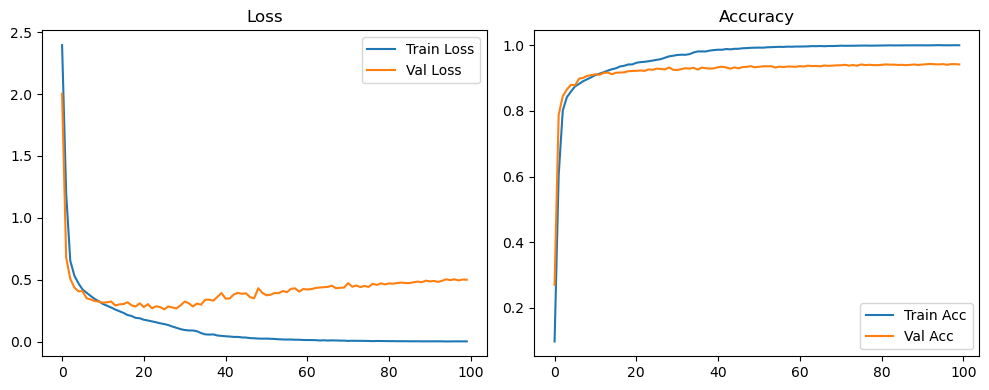

Evaluation:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|█▍        | 1/7 [00:00<00:03,  1.62it/s]

Evaluation:  29%|██▊       | 2/7 [00:00<00:01,  2.75it/s]

Evaluation:  43%|████▎     | 3/7 [00:00<00:01,  3.53it/s]

Evaluation:  57%|█████▋    | 4/7 [00:01<00:00,  4.08it/s]

...

| LR: 0.000011 | Train Acc: 0.9986 | Val Acc: 0.9410 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [23:56<00:13, 13.96s/it]

| LR: 0.000010 | Train Acc: 0.9984 | Val Acc: 0.9416 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [24:10<00:13, 13.96s/it]

| LR: 0.000010 | Train Acc: 0.9984 | Val Acc: 0.9416 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [24:10<00:13, 13.96s/it]

| LR: 0.000010 | Train Acc: 0.9984 | Val Acc: 0.9416 | Epoch Time: 0.23 | : 100%|██████████| 100/100 [24:10<00:00, 13.97s/it]

| LR: 0.000010 | Train Acc: 0.9984 | Val Acc: 0.9416 | Epoch Time: 0.23 | : 100%|██████████| 100/100 [24:10<00:00, 14.50s/it]

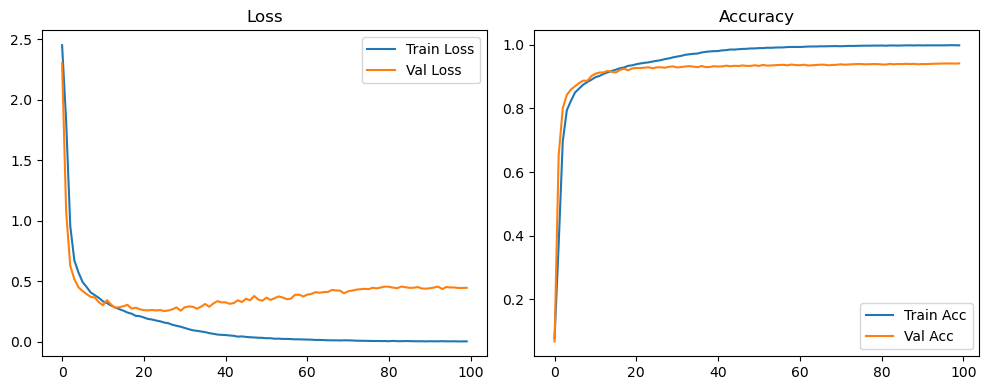

Evaluation:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|█▍        | 1/7 [00:00<00:03,  1.70it/s]

Evaluation:  29%|██▊       | 2/7 [00:00<00:01,  2.83it/s]

Evaluation:  43%|████▎     | 3/7 [00:00<00:01,  3.62it/s]

Evaluation:  57%|█████▋    | 4/7 [00:01<00:00,  4.15it/s]

...

| LR: 0.000002 | Train Acc: 0.9998 | Val Acc: 0.9340 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [23:17<00:13, 13.60s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9348 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [23:30<00:13, 13.60s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9348 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [23:30<00:13, 13.60s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9348 | Epoch Time: 0.23 | : 100%|██████████| 100/100 [23:30<00:00, 13.60s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9348 | Epoch Time: 0.23 | : 100%|██████████| 100/100 [23:30<00:00, 14.11s/it]

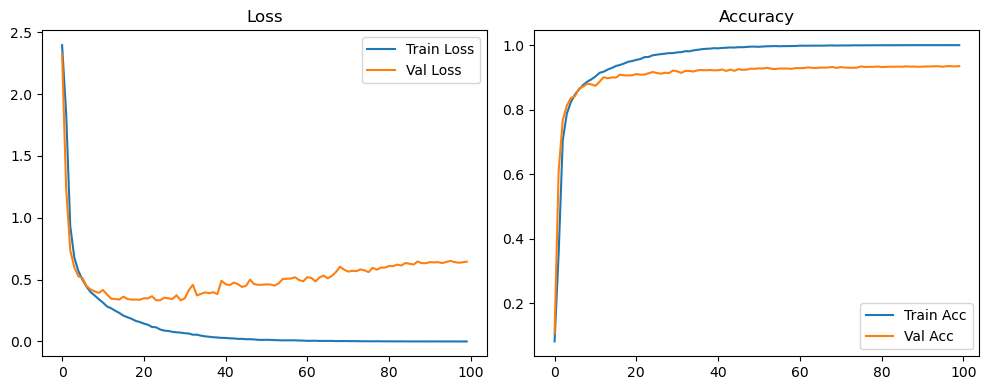

Evaluation:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|█▍        | 1/7 [00:00<00:03,  1.63it/s]

Evaluation:  29%|██▊       | 2/7 [00:00<00:01,  2.75it/s]

Evaluation:  43%|████▎     | 3/7 [00:00<00:01,  3.54it/s]

Evaluation:  57%|█████▋    | 4/7 [00:01<00:00,  4.07it/s]

...

| LR: 0.000002 | Train Acc: 0.9989 | Val Acc: 0.9397 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [23:58<00:13, 13.97s/it]

| LR: 0.000001 | Train Acc: 0.9986 | Val Acc: 0.9400 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [24:12<00:13, 13.97s/it]

| LR: 0.000001 | Train Acc: 0.9986 | Val Acc: 0.9400 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [24:12<00:13, 13.97s/it]

| LR: 0.000001 | Train Acc: 0.9986 | Val Acc: 0.9400 | Epoch Time: 0.23 | : 100%|██████████| 100/100 [24:12<00:00, 14.00s/it]

| LR: 0.000001 | Train Acc: 0.9986 | Val Acc: 0.9400 | Epoch Time: 0.23 | : 100%|██████████| 100/100 [24:12<00:00, 14.53s/it]

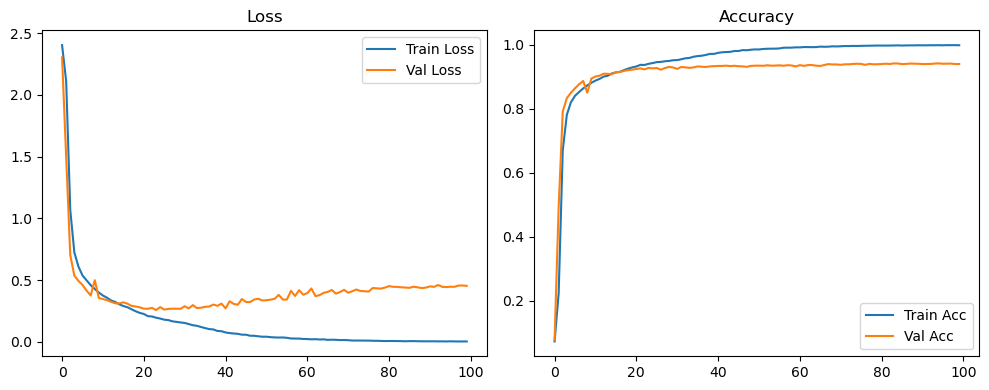

Evaluation:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|█▍        | 1/7 [00:00<00:03,  1.56it/s]

Evaluation:  29%|██▊       | 2/7 [00:00<00:01,  2.68it/s]

Evaluation:  43%|████▎     | 3/7 [00:01<00:01,  3.47it/s]

Evaluation:  57%|█████▋    | 4/7 [00:01<00:00,  4.03it/s]

...

| LR: 0.000002 | Train Acc: 0.9940 | Val Acc: 0.9401 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [23:59<00:13, 14.00s/it]

| LR: 0.000001 | Train Acc: 0.9946 | Val Acc: 0.9405 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [24:13<00:13, 14.00s/it]

| LR: 0.000001 | Train Acc: 0.9946 | Val Acc: 0.9405 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [24:13<00:13, 14.00s/it]

| LR: 0.000001 | Train Acc: 0.9946 | Val Acc: 0.9405 | Epoch Time: 0.23 | : 100%|██████████| 100/100 [24:13<00:00, 13.98s/it]

| LR: 0.000001 | Train Acc: 0.9946 | Val Acc: 0.9405 | Epoch Time: 0.23 | : 100%|██████████| 100/100 [24:13<00:00, 14.53s/it]

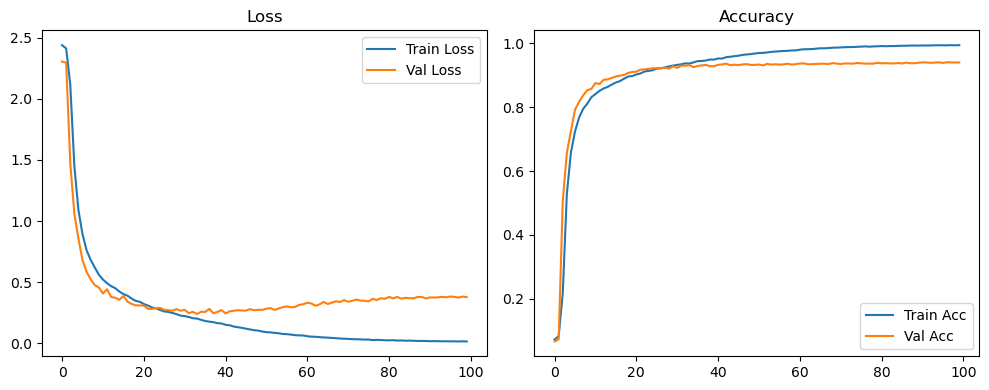

Evaluation:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|█▍        | 1/7 [00:00<00:03,  1.58it/s]

Evaluation:  29%|██▊       | 2/7 [00:00<00:01,  2.69it/s]

Evaluation:  43%|████▎     | 3/7 [00:01<00:01,  3.48it/s]

Evaluation:  57%|█████▋    | 4/7 [00:01<00:00,  4.03it/s]

...

| LR: 0.000010 | Train Acc: 0.9996 | Val Acc: 0.9348 | Epoch Time: 0.21 | :  99%|█████████▉| 99/100 [22:53<00:12, 12.92s/it]

| LR: 0.000010 | Train Acc: 0.9997 | Val Acc: 0.9333 | Epoch Time: 0.21 | :  99%|█████████▉| 99/100 [23:06<00:12, 12.92s/it]

| LR: 0.000010 | Train Acc: 0.9997 | Val Acc: 0.9333 | Epoch Time: 0.21 | :  99%|█████████▉| 99/100 [23:06<00:12, 12.92s/it]

| LR: 0.000010 | Train Acc: 0.9997 | Val Acc: 0.9333 | Epoch Time: 0.21 | : 100%|██████████| 100/100 [23:06<00:00, 12.91s/it]

| LR: 0.000010 | Train Acc: 0.9997 | Val Acc: 0.9333 | Epoch Time: 0.21 | : 100%|██████████| 100/100 [23:06<00:00, 13.86s/it]

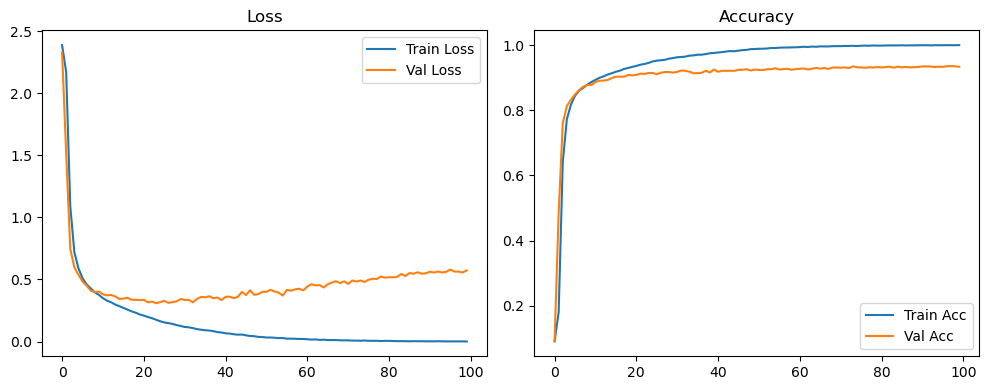

Evaluation:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|█▍        | 1/7 [00:00<00:03,  1.71it/s]

Evaluation:  29%|██▊       | 2/7 [00:00<00:01,  2.90it/s]

Evaluation:  43%|████▎     | 3/7 [00:00<00:01,  3.72it/s]

Evaluation:  57%|█████▋    | 4/7 [00:01<00:00,  4.30it/s]

...

| LR: 0.000010 | Train Acc: 0.9972 | Val Acc: 0.9404 | Epoch Time: 0.22 | :  99%|█████████▉| 99/100 [22:43<00:13, 13.26s/it]

| LR: 0.000010 | Train Acc: 0.9969 | Val Acc: 0.9395 | Epoch Time: 0.22 | :  99%|█████████▉| 99/100 [22:57<00:13, 13.26s/it]

| LR: 0.000010 | Train Acc: 0.9969 | Val Acc: 0.9395 | Epoch Time: 0.22 | :  99%|█████████▉| 99/100 [22:57<00:13, 13.26s/it]

| LR: 0.000010 | Train Acc: 0.9969 | Val Acc: 0.9395 | Epoch Time: 0.22 | : 100%|██████████| 100/100 [22:57<00:00, 13.24s/it]

| LR: 0.000010 | Train Acc: 0.9969 | Val Acc: 0.9395 | Epoch Time: 0.22 | : 100%|██████████| 100/100 [22:57<00:00, 13.77s/it]

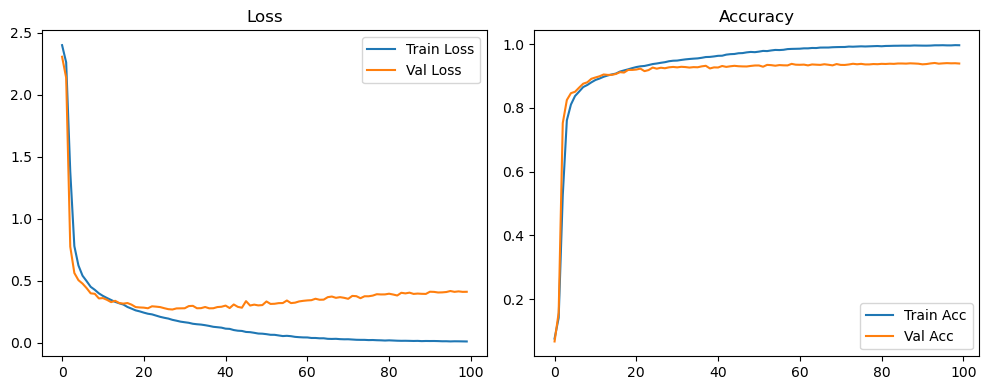

Evaluation:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|█▍        | 1/7 [00:00<00:03,  1.67it/s]

Evaluation:  29%|██▊       | 2/7 [00:00<00:01,  2.84it/s]

Evaluation:  43%|████▎     | 3/7 [00:00<00:01,  3.66it/s]

Evaluation:  57%|█████▋    | 4/7 [00:01<00:00,  4.25it/s]

...

| LR: 0.000010 | Train Acc: 0.9905 | Val Acc: 0.9391 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [23:35<00:13, 13.98s/it]

| LR: 0.000010 | Train Acc: 0.9904 | Val Acc: 0.9401 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [23:49<00:13, 13.98s/it]

| LR: 0.000010 | Train Acc: 0.9904 | Val Acc: 0.9401 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [23:49<00:13, 13.98s/it]

| LR: 0.000010 | Train Acc: 0.9904 | Val Acc: 0.9401 | Epoch Time: 0.23 | : 100%|██████████| 100/100 [23:49<00:00, 13.97s/it]

| LR: 0.000010 | Train Acc: 0.9904 | Val Acc: 0.9401 | Epoch Time: 0.23 | : 100%|██████████| 100/100 [23:49<00:00, 14.30s/it]

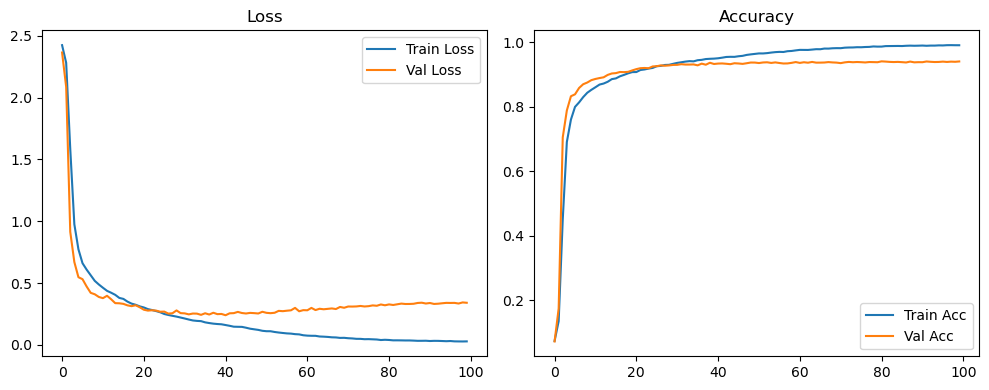

Evaluation:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|█▍        | 1/7 [00:00<00:03,  1.62it/s]

Evaluation:  29%|██▊       | 2/7 [00:00<00:01,  2.74it/s]

Evaluation:  43%|████▎     | 3/7 [00:00<00:01,  3.51it/s]

Evaluation:  57%|█████▋    | 4/7 [00:01<00:00,  4.07it/s]

...

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9380 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [23:17<00:13, 13.60s/it]

| LR: 0.000001 | Train Acc: 0.9997 | Val Acc: 0.9380 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [23:30<00:13, 13.60s/it]

| LR: 0.000001 | Train Acc: 0.9997 | Val Acc: 0.9380 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [23:30<00:13, 13.60s/it]

| LR: 0.000001 | Train Acc: 0.9997 | Val Acc: 0.9380 | Epoch Time: 0.23 | : 100%|██████████| 100/100 [23:30<00:00, 13.61s/it]

| LR: 0.000001 | Train Acc: 0.9997 | Val Acc: 0.9380 | Epoch Time: 0.23 | : 100%|██████████| 100/100 [23:30<00:00, 14.11s/it]

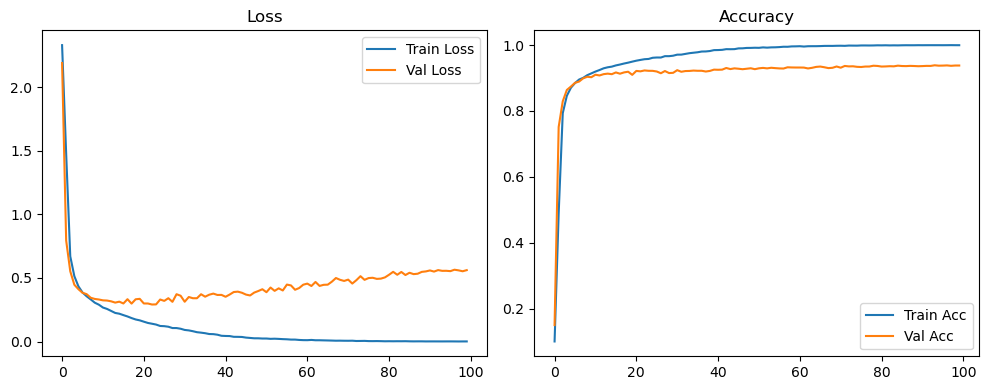

Evaluation:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|█▍        | 1/7 [00:00<00:03,  1.61it/s]

Evaluation:  29%|██▊       | 2/7 [00:00<00:01,  2.74it/s]

Evaluation:  43%|████▎     | 3/7 [00:00<00:01,  3.52it/s]

Evaluation:  57%|█████▋    | 4/7 [00:01<00:00,  4.08it/s]

...

| LR: 0.000001 | Train Acc: 0.9981 | Val Acc: 0.9377 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [23:58<00:14, 14.01s/it]

| LR: 0.000001 | Train Acc: 0.9984 | Val Acc: 0.9369 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [24:12<00:14, 14.01s/it]

| LR: 0.000001 | Train Acc: 0.9984 | Val Acc: 0.9369 | Epoch Time: 0.23 | :  99%|█████████▉| 99/100 [24:12<00:14, 14.01s/it]

| LR: 0.000001 | Train Acc: 0.9984 | Val Acc: 0.9369 | Epoch Time: 0.23 | : 100%|██████████| 100/100 [24:12<00:00, 13.99s/it]

| LR: 0.000001 | Train Acc: 0.9984 | Val Acc: 0.9369 | Epoch Time: 0.23 | : 100%|██████████| 100/100 [24:12<00:00, 14.52s/it]

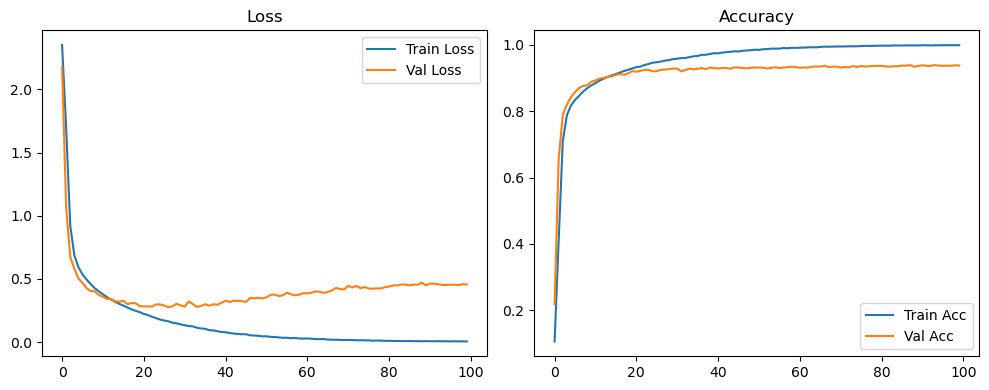

Evaluation:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|█▍        | 1/7 [00:00<00:04,  1.49it/s]

Evaluation:  29%|██▊       | 2/7 [00:00<00:01,  2.58it/s]

Evaluation:  43%|████▎     | 3/7 [00:01<00:01,  3.37it/s]

Evaluation:  57%|█████▋    | 4/7 [00:01<00:00,  3.94it/s]

...

| LR: 0.000001 | Train Acc: 0.9923 | Val Acc: 0.9414 | Epoch Time: 0.22 | :  99%|█████████▉| 99/100 [23:32<00:13, 13.29s/it]

| LR: 0.000001 | Train Acc: 0.9924 | Val Acc: 0.9406 | Epoch Time: 0.22 | :  99%|█████████▉| 99/100 [23:45<00:13, 13.29s/it]

| LR: 0.000001 | Train Acc: 0.9924 | Val Acc: 0.9406 | Epoch Time: 0.22 | :  99%|█████████▉| 99/100 [23:45<00:13, 13.29s/it]

| LR: 0.000001 | Train Acc: 0.9924 | Val Acc: 0.9406 | Epoch Time: 0.22 | : 100%|██████████| 100/100 [23:45<00:00, 13.28s/it]

| LR: 0.000001 | Train Acc: 0.9924 | Val Acc: 0.9406 | Epoch Time: 0.22 | : 100%|██████████| 100/100 [23:45<00:00, 14.26s/it]

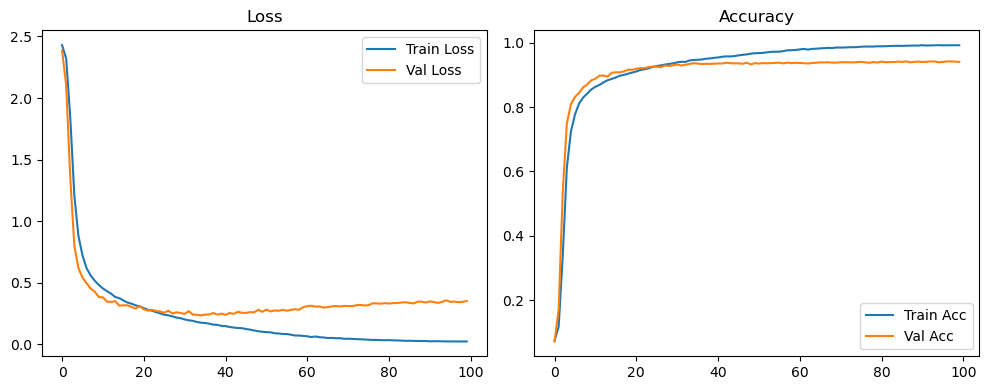

Evaluation:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|█▍        | 1/7 [00:00<00:03,  1.60it/s]

Evaluation:  29%|██▊       | 2/7 [00:00<00:01,  2.77it/s]

Evaluation:  43%|████▎     | 3/7 [00:00<00:01,  3.60it/s]

Evaluation:  57%|█████▋    | 4/7 [00:01<00:00,  4.20it/s]

Evaluation:  71%|███████▏  | 5/7 [00:01<00:00,  4.62it/s]

Evaluation:  86%|████████▌ | 6/7 [00:01<00:00,  4.91it/s]

Evaluation: 100%|██████████| 7/7 [00:01<00:00,  4.43it/s]

Original Model Final Test Loss: 0.2991 Accuracy: 0.9474




In [21]:
best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path  = Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates)

In [22]:
best_evaluation(best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path)

Using downloaded and verified file: /home/hippocampus/workspace/Projects/Software/Python/QModels-Brevitas-Example/brevitas_std_qnn/classification/SVHN/perTensor/dataset/SVHN/train_32x32.mat


Using downloaded and verified file: /home/hippocampus/workspace/Projects/Software/Python/QModels-Brevitas-Example/brevitas_std_qnn/classification/SVHN/perTensor/dataset/SVHN/test_32x32.mat


Best model loaded.


Evaluation:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|█▍        | 1/7 [00:00<00:04,  1.31it/s]

...

Evaluation:  57%|█████▋    | 4/7 [00:01<00:00,  3.88it/s]

Evaluation:  71%|███████▏  | 5/7 [00:01<00:00,  4.37it/s]

Evaluation:  86%|████████▌ | 6/7 [00:01<00:00,  4.73it/s]

Evaluation: 100%|██████████| 7/7 [00:01<00:00,  4.07it/s]

Best Original Model Final Test Loss: 0.2991 Acc: 0.9474 


